In [ ]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

c:\Users\user\Desktop\younes\data_exploration\uv_project


In [15]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [16]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import calendar
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from scipy.stats import pearsonr
from plotly import express as px
import altair as alt
from matplotlib.ticker import LogLocator


from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

from utilsforecast.plotting import plot_series as plot_series_utils
import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(30)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

polars.config.Config

In [ ]:
import main
import lib
import read_data
import importlib

importlib.reload(lib)
importlib.reload(main)

data = read_data.read_smi_suiviexpedition_many()

In [18]:
print(data)

shape: (244_147, 9)
┌─────────────────────────┬──────────────────────┬─────────────────────┬────────────────────────────┬───────────┬────────────────┬─────────────────────┬────────────────────────────────┬──────────────┐
│ CAB                     ┆ CLIENT               ┆ SERVICES_OPTIONNELS ┆ SITE_EXPEDITEUR            ┆ RECEPTION ┆ DERNIER_STATUT ┆ DATE_DERNIER_STATUT ┆ SITE_DERNIER_STATUT            ┆ DESTINATION  │
│ ---                     ┆ ---                  ┆ ---                 ┆ ---                        ┆ ---       ┆ ---            ┆ ---                 ┆ ---                            ┆ ---          │
│ str                     ┆ str                  ┆ str                 ┆ str                        ┆ str       ┆ str            ┆ datetime[μs]        ┆ str                            ┆ str          │
╞═════════════════════════╪══════════════════════╪═════════════════════╪════════════════════════════╪═══════════╪════════════════╪═════════════════════╪════════════════════════

In [19]:
# def ordered_by_total(df, col):
#     return df.group_by(col).len().sort("len", descending=True)[col].to_list()


def ordered_by_total(df, col):
    return (
        df.group_by(col)
        .agg(pl.col("COUNT").sum())
        .sort("COUNT", descending=True)[col]
        .to_list()
    )


In [20]:
def prepare_data(df, interval, start):
    return (
        df.filter(pl.col("DATE_DERNIER_STATUT").ge(start))
        .group_by_dynamic(
            index_column="DATE_DERNIER_STATUT",
            every=interval,
            group_by=["SITE_DERNIER_STATUT", "DERNIER_STATUT"],
        )
        .agg(pl.len().alias("COUNT"))
        .pipe(
            lib.complete_grid,
            dimensions={
                "SITE_DERNIER_STATUT": lambda d: d["SITE_DERNIER_STATUT"].unique(),
                "DERNIER_STATUT": lambda d: d["DERNIER_STATUT"].unique(),
                "DATE_DERNIER_STATUT": lambda d: pl.datetime_range(
                    d["DATE_DERNIER_STATUT"].min(),
                    d["DATE_DERNIER_STATUT"].max(),
                    interval=interval,
                    eager=True,
                    time_unit="us",
                ),
            },
            fill_value=0,
        )
        # .pipe(lib.complete_time_grid, "SITE_DERNIER_STATUT", "DATE_DERNIER_STATUT", "1mo", "us")
        .with_columns(
            pl.col("DATE_DERNIER_STATUT").dt.strftime("%Y-%m").alias("YEAR_MONTH"),
            pl.col("DATE_DERNIER_STATUT").dt.strftime("%Y").alias("YEAR"),
            pl.col("DATE_DERNIER_STATUT").dt.strftime("%m").alias("MONTH"),
            pl.col("DATE_DERNIER_STATUT").dt.strftime("%b").alias("MONTH_NAME"),
        )
        .sort(["DATE_DERNIER_STATUT"])
        # .with_columns(
        #     pl.when(COUNT=0).then(None).otherwise("COUNT").alias("COUNT")
        # )  # set 0 to null for log transform
    )


In [21]:
print(prepare_data(data, "1mo", pl.date(2024, 1, 1)))

shape: (2_016, 8)
┌──────────────────────────┬────────────────┬─────────────────────┬───────┬────────────┬──────┬───────┬────────────┐
│ SITE_DERNIER_STATUT      ┆ DERNIER_STATUT ┆ DATE_DERNIER_STATUT ┆ COUNT ┆ YEAR_MONTH ┆ YEAR ┆ MONTH ┆ MONTH_NAME │
│ ---                      ┆ ---            ┆ ---                 ┆ ---   ┆ ---        ┆ ---  ┆ ---   ┆ ---        │
│ str                      ┆ str            ┆ datetime[μs]        ┆ u32   ┆ str        ┆ str  ┆ str   ┆ str        │
╞══════════════════════════╪════════════════╪═════════════════════╪═══════╪════════════╪══════╪═══════╪════════════╡
│ AGENCE MESSAGERIE DAKHLA ┆ aexp           ┆ 2024-01-01 00:00:00 ┆ 1     ┆ 2024-01    ┆ 2024 ┆ 01    ┆ Jan        │
│ AGENCE MESSAGERIE DAKHLA ┆ aff            ┆ 2024-01-01 00:00:00 ┆ 0     ┆ 2024-01    ┆ 2024 ┆ 01    ┆ Jan        │
│ AGENCE MESSAGERIE DAKHLA ┆ affg           ┆ 2024-01-01 00:00:00 ┆ 0     ┆ 2024-01    ┆ 2024 ┆ 01    ┆ Jan        │
│ AGENCE MESSAGERIE DAKHLA ┆ chrgctr        ┆ 

In [22]:
df_plot = prepare_data(data, "1y", pl.date(2024, 1, 1))
sites_by_total = ordered_by_total(df_plot, "SITE_DERNIER_STATUT")
status_by_total = ordered_by_total(df_plot, "DERNIER_STATUT")

for site in sites_by_total:
    chart = (
        alt.Chart(df_plot.filter(SITE_DERNIER_STATUT=site))
        .mark_bar()
        .encode(
            x=alt.X("YEAR:O", sort=None, title="Year"),
            y=alt.Y("COUNT:Q", title="Expidition count")
            .scale(type="symlog")
            .axis(values=LogLocator(subs=range(1, 10)).tick_values(10, 1000)),
            color=alt.Color("DERNIER_STATUT:N", title="Status", sort=status_by_total),
            xOffset=alt.XOffset(
                "DERNIER_STATUT:N", title="Status", sort=status_by_total
            ),
        )
        .properties(width=1000, height=250, title=f"{site} (2024-2026)")
        .configure_axisX(labelAngle=-45)
    )

    chart.show()
    # chart.save(f"charts/package_count_by_status_from_2024_to_2026_by_year_{site}.png")

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [23]:
df_plot = prepare_data(data, "1mo", pl.date(2026, 1, 1))
sites_by_total = ordered_by_total(df_plot, "SITE_DERNIER_STATUT")
status_by_total = ordered_by_total(df_plot, "DERNIER_STATUT")

for site in sites_by_total:
    chart = (
        alt.Chart(df_plot.filter(SITE_DERNIER_STATUT=site))
        .mark_bar()
        .encode(
            x=alt.X("YEAR_MONTH:N", sort=None, title="Month"),
            y=alt.Y("COUNT:Q", title="Expidition count")
            .scale(type="symlog")
            .axis(values=LogLocator(subs=range(1, 10)).tick_values(10, 100000)),
            color=alt.Color("DERNIER_STATUT:N", title="Status", sort=status_by_total),
            xOffset=alt.XOffset("DERNIER_STATUT:N", sort=status_by_total),
        )
        .properties(width=1000, height=250, title=f"{site} (2026)")
        .configure_axisX(labelAngle=0)
    )

    chart.show()
    # chart.save(f"charts/package_count_2026_by_month_{site}.png")

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

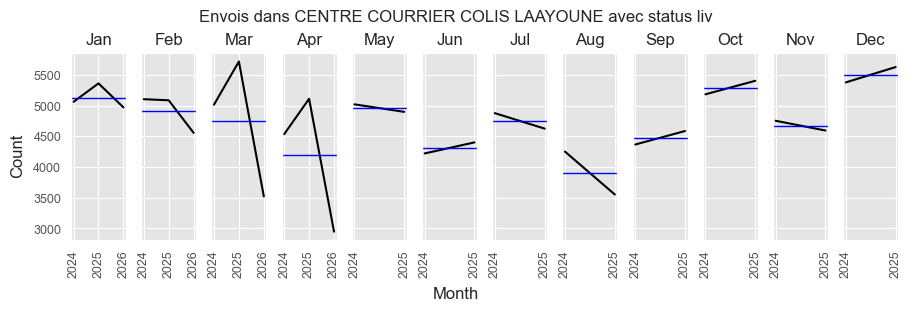

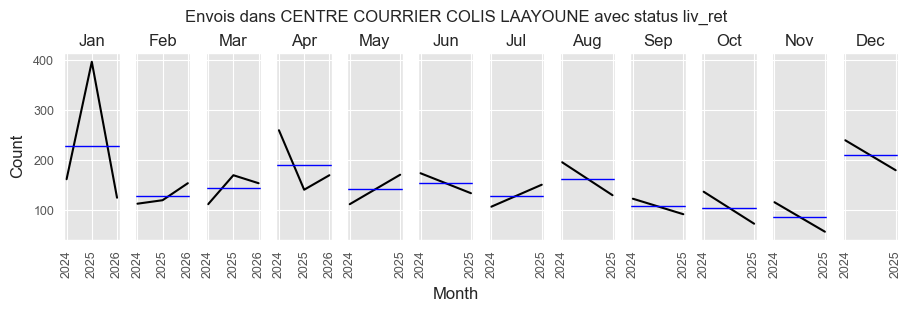

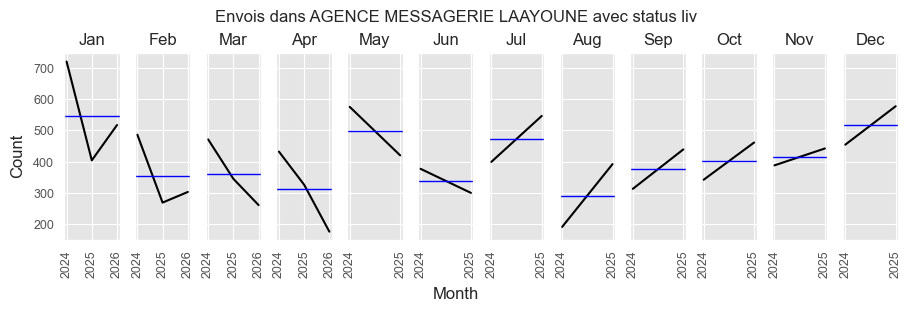

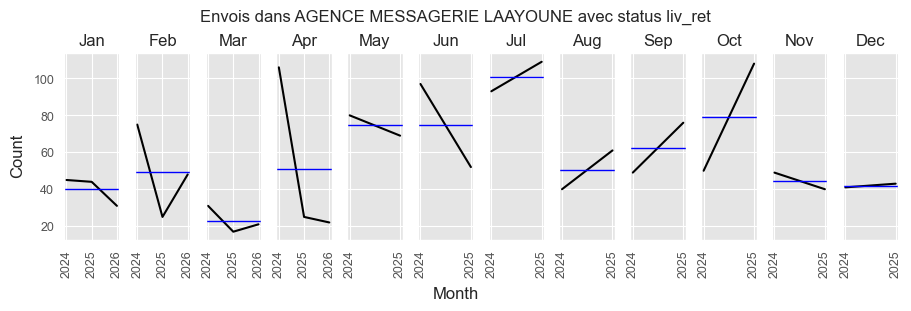

In [ ]:
df_plot = prepare_data(data, "1mo", pl.date(2024, 1, 1))
sites_by_total = ordered_by_total(df_plot, "SITE_DERNIER_STATUT")
status_by_total = ordered_by_total(df_plot, "DERNIER_STATUT")


# df = total_cost_df.assign(
#     year=total_cost_df["Month"].dt.year,
#     month_name=total_cost_df["Month"].dt.month_name(),
#     month_idx=total_cost_df["Month"].dt.month,
# )

for site in sites_by_total[:2]:
    for status in status_by_total[:2]:
        df = df_plot.filter(SITE_DERNIER_STATUT=site, DERNIER_STATUT=status).to_pandas()

        fig, axes = plt.subplots(1, 12, figsize=(9, 3), sharey=True)
        for ax, ((_, month_name), month_df) in zip(
            axes, df.groupby(["MONTH", "MONTH_NAME"])
        ):
            mean_cost = month_df["COUNT"].mean()
            ax.plot(month_df["YEAR"], month_df["COUNT"], color="k")
            ax.axhline(mean_cost, color="b", linewidth=1)
            ax.set(title=month_name[:3], xlabel="")
            ax.tick_params(axis="x", rotation=90)

        fig.suptitle(f"Envois dans {site} avec status {status}")
        fig.supxlabel("Month")
        fig.supylabel("Count")
        fig.show()

In [146]:
df_plot = prepare_data(data, "1mo", pl.date(2023, 1, 1))
sites_by_total = ordered_by_total(df_plot, "SITE_DERNIER_STATUT")
status_by_total = ordered_by_total(df_plot, "DERNIER_STATUT")

df = df_plot.to_pandas()

site_options = ["All"] + list(sites_by_total)
status_options = ["All"] + list(status_by_total)
# year_options = sorted(df["YEAR"].astype(str).unique().tolist())

site_dropdown = alt.binding_select(
    options=site_options,
    name="Site: ",
)

status_dropdown = alt.binding_select(
    options=status_options,
    name="Status: ",
)

# year_start_dropdown = alt.binding_select(
#     options=year_options,
#     name="Start Year: ",
# )

# year_end_dropdown = alt.binding_select(
#     options=year_options,
#     name="End Year: ",
# )

site_param = alt.param(
    value="All",
    bind=site_dropdown,
    name="site",
)

status_param = alt.param(
    value="All",
    bind=status_dropdown,
    name="status",
)

# year_start_param = alt.param(
#     value=year_options[0],
#     bind=year_start_dropdown,
#     name="year_start",
# )

# year_end_param = alt.param(
#     value=year_options[-1],
#     bind=year_end_dropdown,
#     name="year_end",
# )


base = alt.Chart(df).transform_filter(
    "(site == 'All' || datum.SITE_DERNIER_STATUT == site)"
    "&& (status == 'All' || datum.DERNIER_STATUT == status)"
    # "&& (datum.YEAR >= toNumber(year_start))"
    # "&& (datum.YEAR <= toNumber(year_end))"
)

line = base.mark_line(color="black").encode(
    x=alt.X("YEAR:O", title=None),
    y=alt.Y("sum(COUNT):Q", title="Count"),
    tooltip=[
        "MONTH_NAME",
        "YEAR",
        alt.Tooltip("sum(COUNT):Q", title="Total Count"),
    ],
)

mean_line = (
    base.transform_aggregate(
        total_count="sum(COUNT)",
        groupby=["MONTH", "MONTH_NAME", "YEAR"],
    )
    .mark_rule(color="steelblue")
    .encode(y="mean(total_count):Q")
)

title = alt.Title(
    alt.expr(
        "'Envoi count by Month and Year -- Site: ' + site"
        " + ' -- status: ' + status"
        # " + ' -- Years: ' + year_start + ' to ' + year_end"
    )
)

chart = (
    (line + mean_line)
    .facet(
        column=alt.Column(
            "MONTH_NAME:N",
            sort=alt.SortField("MONTH"),
            title=None,
        )
    )
    .add_params(
        site_param,
        status_param,
        # year_start_param,
        # year_end_param,
    )
    .properties(title=title)
    .resolve_scale(y="shared")
)

chart.save("charts/Envoi count by Month and Year.html")
chart

alt.FacetChart(...)